# SurgSAM-2 on Whipple surgical videos — proof of concept

Pipeline state:
1. **`run_on_video.py`** — CLI on top of SurgSAM-2. Takes an mp4 or a frames directory; supports multi-instrument prompts via `--object OBJID:x,y[,x,y...]`; handles the lab's whip frame naming (`frame_NNNNNNNNNN.png`); writes browser-friendly H.264 overlays.
2. **First whip clip (DC_whip_11609423)** — single-instrument segmentation (the metallic clamp) propagated across 2590 frames in ~80s on one RTX 3090. See section 1.
3. **Multi-instrument run** — same clip, two instruments tracked simultaneously. See section "Multi-instrument whip run".
4. **Quantitative validation on EndoVis18 seq_2** — baseline J&F = 76.95, ceiling with periodic re-prompting J&F = 89.19. See "EndoVis18 quantitative evaluation".
5. **Scaling stub** — flip on additional whip videos in the last cell.

Code is version-controlled and synced to bigpurple at `bigpurple:/gpfs/data/oermannlab/users/schula12/Surgical-SAM-2/` (branch `training`).

In [1]:
from pathlib import Path

RESULTS_DIR = Path('results/DC_whip_11609423_metallic')
FRAMES_DIR  = Path('test_data/DC_whip_11609423')

OVERLAY_DIR = RESULTS_DIR / 'overlay'
MASKS_DIR   = RESULTS_DIR / 'masks'

# run_on_video.py writes overlay.mp4 with the mp4v fourcc, which Firefox/Chrome
# refuse to play inline. Re-encode to H.264 once (using the bundled
# imageio-ffmpeg binary) and cache as overlay_h264.mp4.
import subprocess, imageio_ffmpeg
src = RESULTS_DIR / 'overlay.mp4'
OVERLAY_VIDEO = RESULTS_DIR / 'overlay_h264.mp4'
if not OVERLAY_VIDEO.exists():
    print('Re-encoding to H.264 (one-time) ...')
    subprocess.run([imageio_ffmpeg.get_ffmpeg_exe(), '-y', '-i', str(src),
                    '-c:v', 'libx264', '-pix_fmt', 'yuv420p',
                    '-movflags', '+faststart', str(OVERLAY_VIDEO)],
                   check=True)
print('overlay video :', OVERLAY_VIDEO, f'({OVERLAY_VIDEO.stat().st_size/1e6:.1f} MB)')
print('per-frame imgs:', len(list(OVERLAY_DIR.glob('*.jpg'))), 'overlays /',
      len(list(MASKS_DIR.glob('*.png'))), 'masks')

overlay video : results/DC_whip_11609423_metallic/overlay_h264.mp4 (85.2 MB)
per-frame imgs: 2590 overlays / 2590 masks


## 1) Play the overlay video inline

In [2]:
from IPython.display import Video
Video(str(OVERLAY_VIDEO), embed=False, width=720, height=480)

## 2) Slider: original | mask | overlay

`out_idx` is the index used in output filenames (re-indexed from 0). `source_idx` is the original whip frame number — useful when cross-referencing the `pj_annotations_*.csv` phase labels.

In [3]:
import re
FRAME_RE = re.compile(r'^frame_(\d+)$')
src_frames = sorted(FRAMES_DIR.glob('frame_*.png'))
src_idx_per_out = [int(FRAME_RE.match(p.stem).group(1)) for p in src_frames]
print(f'{len(src_idx_per_out)} frames, source idx range '
      f'{src_idx_per_out[0]}..{src_idx_per_out[-1]}')

2590 frames, source idx range 315..26367


In [4]:
import matplotlib.pyplot as plt
from PIL import Image
import ipywidgets as widgets
from IPython.display import display

n = len(src_idx_per_out)

def show(out_idx):
    src_idx = src_idx_per_out[out_idx]
    orig = Image.open(FRAMES_DIR / f'frame_{src_idx:010d}.png')
    mask = Image.open(MASKS_DIR / f'{out_idx:05d}.png')
    ovly = Image.open(OVERLAY_DIR / f'{out_idx:05d}.jpg')
    fig, axs = plt.subplots(1, 3, figsize=(15, 4))
    for ax, img, title in zip(axs, [orig, mask, ovly],
                              [f'original (src {src_idx})',
                               f'mask (out {out_idx:05d})',
                               'overlay']):
        ax.imshow(img); ax.set_title(title); ax.axis('off')
    plt.tight_layout(); plt.show()

slider = widgets.IntSlider(value=0, min=0, max=n-1, step=1, description='out_idx',
                           continuous_update=False, layout=widgets.Layout(width='90%'))
widgets.interact(show, out_idx=slider);

interactive(children=(IntSlider(value=0, continuous_update=False, description='out_idx', layout=Layout(width='…

## 3) Phase annotations (optional)

If you have a local copy of `pj_annotations_*.csv`, you can find which phase a given source frame falls into here.

In [5]:
# import pandas as pd
# anno = pd.read_csv('path/to/pj_annotations_nov7.csv')
# row = anno[anno['video'].str.contains('DC_whip_11609423')]
# row.T

# EndoVis18 quantitative evaluation

This section analyses the `tools/vos_inference.py` output for EndoVis18 seq_2 — the only validation sequence with both images and GT masks present locally. The baseline run prompts only on frame 0; an optional re-prompt run uses GT at every annotated frame to show the ceiling.

In [6]:
import pandas as pd
import numpy as np
from PIL import Image
from pathlib import Path

ENDOVIS_GT      = Path('datasets/VOS-Endovis18/valid/Annotations/seq_2')
ENDOVIS_IMG     = Path('datasets/endovis18/images/seq_2')
EV_BASELINE     = Path('results/endovis18_seq2_eval/seq_2')
EV_REPROMPT     = Path('results/endovis18_seq2_reprompt/seq_2')

def load_results_csv(p):
    rows = []
    with open(p) as f:
        for line in f:
            if line.startswith('Epoch') or not line.strip(): continue
            rows.append([x.strip() for x in line.split(',')])
    df = pd.DataFrame(rows[1:], columns=rows[0])
    for col in ['J&F', 'J', 'F', 'Dice']:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    return df

baseline_df = load_results_csv('results/endovis18_seq2_eval/results.csv')
baseline_df

,sequence,obj,J&F,J,F,Dice
0,Global score,,76.95,76.55,77.35,79.75
1,seq_2,001,88.77,89.16,88.38,93.15
2,seq_2,002,64.04,64.32,63.76,68.24
3,seq_2,003,75.07,76.45,73.70,79.07
4,seq_2,004,95.51,91.19,99.84,95.37
5,seq_2,007,61.35,61.64,61.06,62.89


## Per-frame IoU per object — baseline
Shows where each object drifts or is lost. Gaps mean the object is absent from GT in that frame.

In [ ]:
import matplotlib.pyplot as plt

def per_frame_iou(pred_root, gt_root):
    """Return dict obj_id -> (frame_names, iou_array). NaN where GT object absent."""
    frames = sorted(p.stem for p in gt_root.glob('*.png'))
    obj_ids = sorted(int(d.name) for d in pred_root.iterdir() if d.is_dir() and d.name.isdigit())
    out = {}
    for oid in obj_ids:
        arr = []
        for f in frames:
            gt = np.array(Image.open(gt_root / f'{f}.png'))
            gt_m = (gt == oid)
            if not gt_m.any():
                arr.append(np.nan); continue
            pp = pred_root / f'{oid:03d}' / f'{f}.png'
            if not pp.exists():
                arr.append(0.0); continue
            pred = np.array(Image.open(pp))
            pred_m = (pred == oid)
            inter = (gt_m & pred_m).sum(); union = (gt_m | pred_m).sum()
            arr.append(inter / union if union else np.nan)
        out[oid] = (frames, np.array(arr))
    return out

baseline_ious = per_frame_iou(EV_BASELINE, ENDOVIS_GT)

fig, ax = plt.subplots(figsize=(12, 4.5))
for oid, (frames, arr) in baseline_ious.items():
    jf = float(baseline_df[baseline_df['obj'] == f'{oid:03d}']['J&F'].iloc[0])
    x = np.arange(len(frames))
    ax.plot(x, arr, marker='o', ms=3, lw=1.2, label=f'obj {oid}  (overall J&F = {jf:.1f})')
ax.set_xlabel('frame index (0 = prompt frame)')
ax.set_ylabel('IoU at this frame  (1.0 = perfect overlap with GT)')
ax.set_ylim(0, 1.05); ax.set_xlim(0, len(next(iter(baseline_ious.values()))[0])-1)
ax.axhline(0.5, color='gray', lw=0.5, ls=':')
ax.grid(alpha=0.3)
ax.legend(loc='lower left', title='instrument', ncol=2)
ax.set_title('EndoVis18 seq_2 — per-frame IoU per instrument\nbaseline run: prompted only on frame 0, propagates forward unaided')
plt.tight_layout(); plt.show()
print('Flat line near 1.0 = good tracking. Line diving toward 0 = the model lost the instrument.')
print('Gaps mean the GT says the instrument is not visible in that frame.')

## Worst-frame inspection
Side-by-side original / GT / pred for the worst case of each weak object.

worst cases: [(1, '00019'), (2, '00097'), (3, '00096'), (4, '00136'), (7, '00010')]


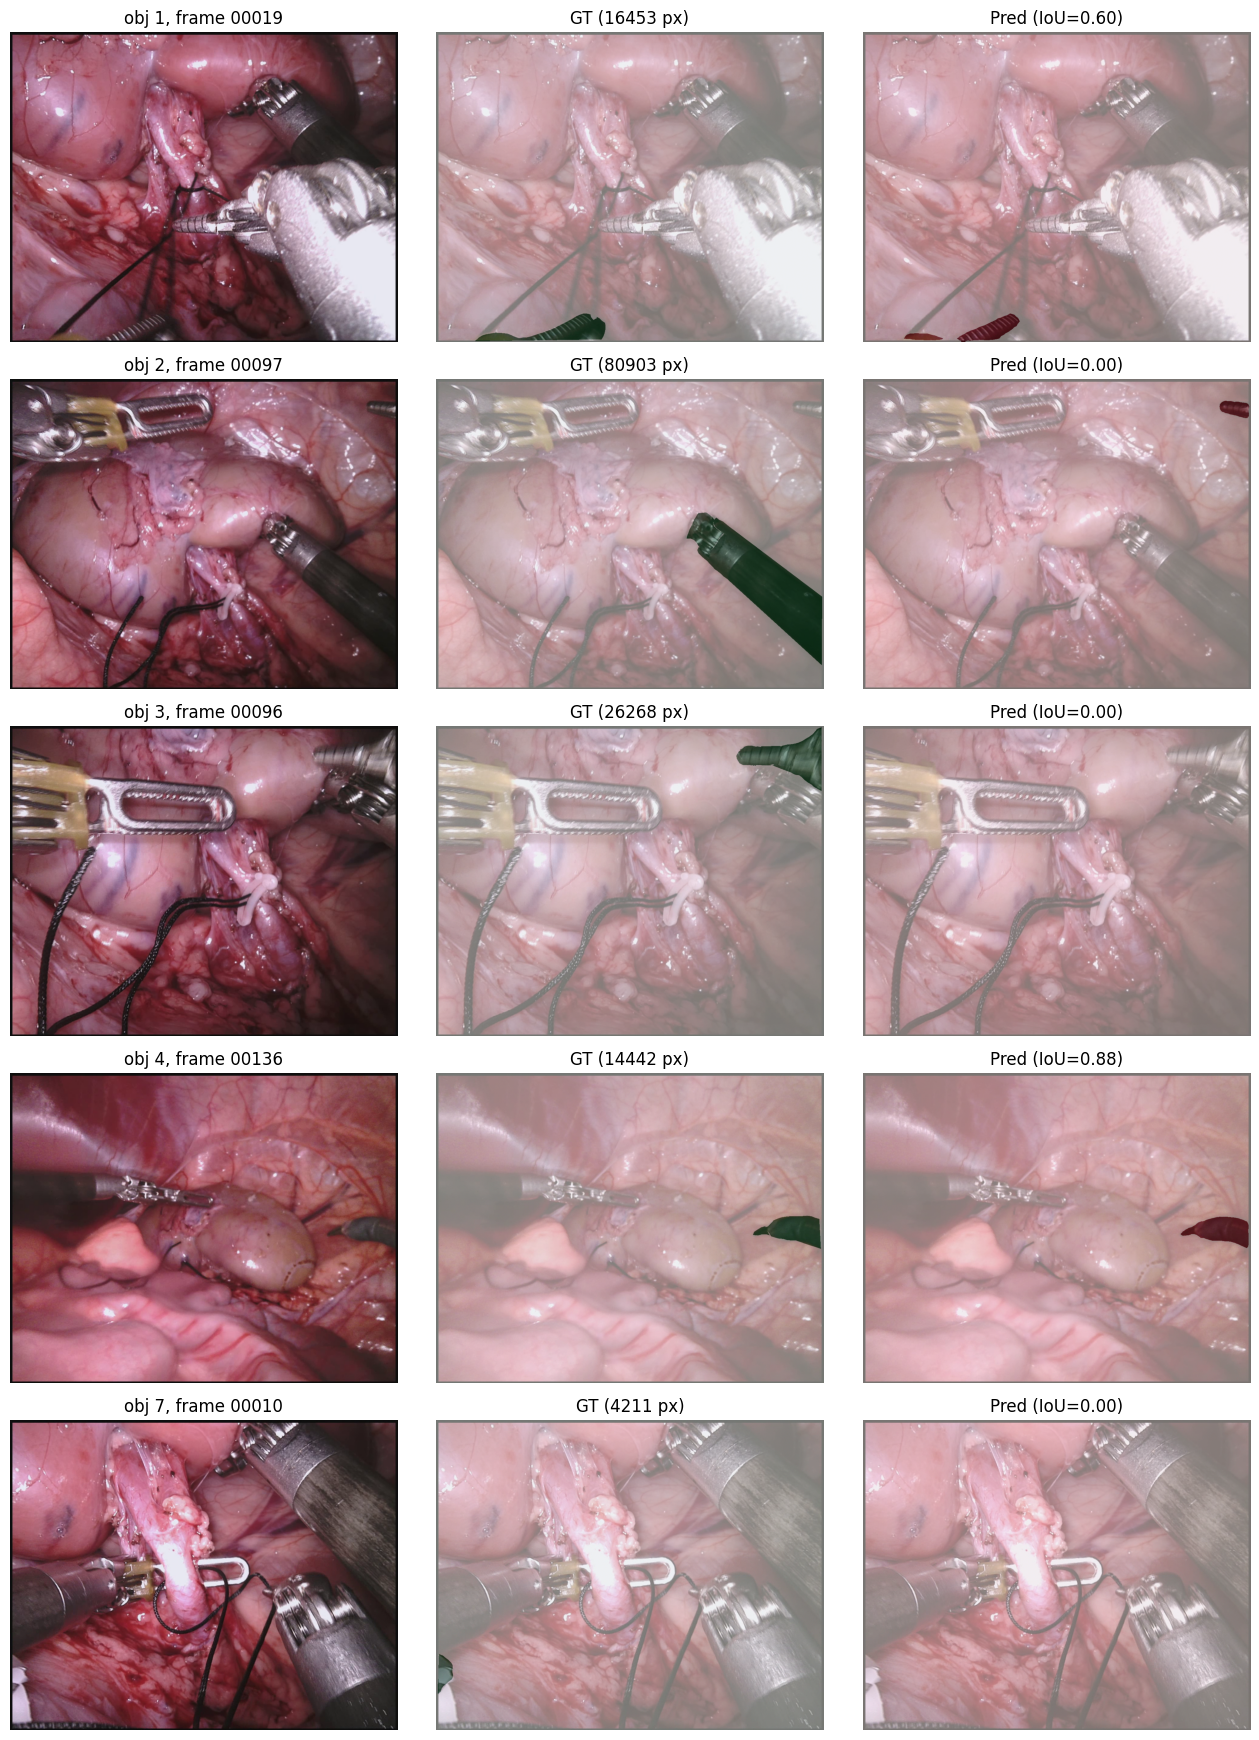

In [8]:
def show_cases(cases, pred_root=EV_BASELINE):
    """cases: list of (obj_id, frame_id) pairs."""
    fig, axes = plt.subplots(len(cases), 3, figsize=(13, 3.5*len(cases)))
    if len(cases) == 1: axes = axes[None, :]
    for i, (oid, fid) in enumerate(cases):
        img = np.array(Image.open(ENDOVIS_IMG / f'{fid}.png').convert('RGB'))
        gt = np.array(Image.open(ENDOVIS_GT / f'{fid}.png'))
        pred = np.array(Image.open(pred_root / f'{oid:03d}' / f'{fid}.png'))
        gt_m = (gt == oid); pred_m = (pred == oid)
        inter = (gt_m & pred_m).sum(); union = (gt_m | pred_m).sum()
        iou = inter/union if union else float('nan')
        axes[i,0].imshow(img); axes[i,0].set_title(f'obj {oid}, frame {fid}')
        axes[i,1].imshow(img); axes[i,1].imshow(gt_m, alpha=0.45, cmap='Greens')
        axes[i,1].set_title(f'GT ({gt_m.sum()} px)')
        axes[i,2].imshow(img); axes[i,2].imshow(pred_m, alpha=0.45, cmap='Reds')
        axes[i,2].set_title(f'Pred (IoU={iou:.2f})')
        for ax in axes[i]: ax.axis('off')
    plt.tight_layout(); plt.show()

# Auto-pick the worst non-NaN frame per object
worst_cases = []
for oid, (frames, arr) in baseline_ious.items():
    if np.all(np.isnan(arr)): continue
    i = int(np.nanargmin(arr))
    worst_cases.append((oid, frames[i]))
print('worst cases:', worst_cases)
show_cases(worst_cases)

## Re-prompt comparison
Once `vos_inference.py` has been re-run with `--use_all_masks` (output at `results/endovis18_seq2_reprompt/`), this cell renders baseline vs. re-prompt side by side. If the directory is missing, the cell skips gracefully.

In [ ]:
reprompt_csv = Path('results/endovis18_seq2_reprompt/results.csv')
if not reprompt_csv.exists():
    print('No re-prompt results yet. Re-run vos_inference.py with --use_all_masks --output_mask_dir ./results/endovis18_seq2_reprompt')
else:
    reprompt_df = load_results_csv(reprompt_csv)
    merged = baseline_df.merge(reprompt_df, on=['sequence', 'obj'], suffixes=('_base', '_reprompt'))
    print('Baseline vs. re-prompt (J&F per instrument, higher = better):')
    print(merged[['sequence','obj','J&F_base','J&F_reprompt']].to_string(index=False))

    reprompt_ious = per_frame_iou(EV_REPROMPT, ENDOVIS_GT)
    n = len(baseline_ious)
    fig, axes = plt.subplots(n, 1, figsize=(12, 2.2*n), sharex=True)
    if n == 1: axes = [axes]
    for ax, (oid, (frames, a)) in zip(axes, baseline_ious.items()):
        x = np.arange(len(frames))
        ax.plot(x, a, marker='o', ms=3, lw=1.2, color='C0', label='baseline (prompt only frame 0)')
        if oid in reprompt_ious:
            _, b = reprompt_ious[oid]
            ax.plot(x, b, marker='s', ms=3, lw=1.2, color='C1', label='re-prompt every frame (uses GT)')
        ax.set_ylabel(f'obj {oid}\nIoU')
        ax.set_ylim(0, 1.05); ax.grid(alpha=0.3)
        ax.axhline(0.5, color='gray', lw=0.5, ls=':')
        ax.legend(loc='lower left', fontsize=8)
    axes[-1].set_xlabel('frame index')
    plt.suptitle('Per-frame IoU: baseline vs. re-prompt — gap between lines = cost of stale prompt',
                 fontsize=11, y=1.0)
    plt.tight_layout(); plt.show()
    print()
    print('Take-away: where the orange (re-prompt) line sits well above blue (baseline), the model could segment')
    print('that instrument fine — it just lost track from a single prompt. A periodic re-prompt strategy (every')
    print('~30 frames, or when mask area collapses) would recover most of that gap on real whip videos where')
    print('we do not have GT masks available.')

# Multi-instrument whip run

Same model, same clip — `DC_whip_11609423` — but now prompting two instruments at frame 0:
- **obj 1** at `(540, 150)` — the metallic clamp upper right
- **obj 2** at `(280, 180)` — the forceps / needle holder in the middle

Each instrument keeps its own colour (DAVIS palette) and is tracked independently across all 2590 frames.

In [ ]:
MULTI_DIR = Path('results/DC_whip_11609423_both')
MULTI_VIDEO = MULTI_DIR / 'overlay_h264.mp4'

if not MULTI_VIDEO.exists():
    src = MULTI_DIR / 'overlay.mp4'
    if src.exists():
        print('Re-encoding multi-instrument overlay to H.264 (one-time) ...')
        subprocess.run([imageio_ffmpeg.get_ffmpeg_exe(), '-y', '-i', str(src),
                        '-c:v', 'libx264', '-pix_fmt', 'yuv420p',
                        '-movflags', '+faststart', str(MULTI_VIDEO)], check=True)
print('Multi-instrument overlay:', MULTI_VIDEO, f'({MULTI_VIDEO.stat().st_size/1e6:.1f} MB)')
Video(str(MULTI_VIDEO), embed=False, width=720, height=480)

# Switch between whip videos for the demo

Each pre-computed result lives in `results/<video>_both/`. To switch which video plays, **comment out all but one** entry below and re-run the cell.

In [ ]:
CHOICES = [
    ('DC_whip_11609423', 'metallic clamp + middle forceps'),
    # ('DG_whip_16598313', 'two laparoscopic clamps'),
    # ('EG_whip_13471773', 'bipolar forceps + metallic upper'),
]

assert len(CHOICES) == 1, 'Comment out all but one entry above.'
video_name, blurb = CHOICES[0]
result_dir = Path('results') / f'{video_name}_both'
overlay_src = result_dir / 'overlay.mp4'
overlay_h264 = result_dir / 'overlay_h264.mp4'

if not overlay_h264.exists():
    if not overlay_src.exists():
        raise FileNotFoundError(
            f'{overlay_src} not found. Run inference on {video_name} first.\n'
            f'Locally:  python run_on_video.py --video test_data/{video_name} --object 1:X,Y --object 2:X,Y --output-dir {result_dir} --fps 1.0\n'
            f'Bigpurple:  edit run_whip_batch.sh to enable {video_name} and sbatch it.'
        )
    print('Re-encoding overlay to H.264 (one-time) ...')
    subprocess.run([imageio_ffmpeg.get_ffmpeg_exe(), '-y', '-i', str(overlay_src),
                    '-c:v', 'libx264', '-pix_fmt', 'yuv420p',
                    '-movflags', '+faststart', str(overlay_h264)], check=True)

print(f'Video: {video_name}  ({blurb})')
print(f'Source: {overlay_h264}  ({overlay_h264.stat().st_size/1e6:.1f} MB)')
Video(str(overlay_h264), embed=False, width=720, height=480)

# Scaling to multiple whip videos

The pipeline is one shell call per video. Uncomment any of the entries below to run inference on additional clips after you've rsynced them from bigpurple to `test_data/`. Each call writes to its own `results/<video>_both/` folder.

```
bigpurple:/gpfs/data/oermannlab/private_data/whip/frames_attempt2/<video_name>/
```

In [ ]:
# Each entry: (video_name, [(obj_id, x, y), ...]). Pick clicks by looking at frame 0 of the clip first.
VIDEOS_TO_RUN = [
    # ('DC_whip_11609423', [(1, 540, 150), (2, 280, 180)]),  # already done above
    # ('DG_whip_16598313', [(1, 600, 200), (2, 300, 250)]),
    # ('DP_whip_16005154', [(1, 500, 180), (2, 250, 200)]),
    # ('JS_whip_12110018', [(1, 550, 170), (2, 270, 220)]),
]

for vid, prompts in VIDEOS_TO_RUN:
    frames_dir = Path('test_data') / vid
    out_dir = Path('results') / f'{vid}_both'
    if not frames_dir.exists():
        print(f'SKIP {vid}: rsync first from '
              f'bigpurple:/gpfs/data/oermannlab/private_data/whip/frames_attempt2/{vid}/')
        continue
    cmd = ['python', 'run_on_video.py',
           '--video', str(frames_dir),
           '--output-dir', str(out_dir),
           '--fps', '1.0']
    for oid, x, y in prompts:
        cmd += ['--object', f'{oid}:{x},{y}']
    print('running:', ' '.join(cmd))
    subprocess.run(cmd, check=True)
    print(f'  -> {out_dir}/overlay.mp4 (re-encode in next cell)')